# cosmock tutorial: from kappa maps to a fitted mock model

This tutorial walks through the kappa-first `cosmock` workflow with synthetic data. It is meant to run without private simulation files. The core fitting and validation sections require only the base package dependencies; the final sampling section runs only when `healpy` is installed.

## Workflow

The supported public workflow is object oriented where state matters:

```python
cal = cosmock.KappaCalibration.from_maps(...)
model = cosmock.MockModel.fit(cal, ...)
mocks = model.sample(...)
report = model.validate(mocks)
```

Lower-level numerical kernels remain available in implementation modules for tests and advanced development, but the tutorial uses the domain objects.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/cosmock-matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/cosmock-cache")

import numpy as np

try:
    import cosmock as cm
except ModuleNotFoundError:
    for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
        if (candidate / "cosmock").exists():
            sys.path.insert(0, str(candidate))
            break
    import cosmock as cm

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

np.set_printoptions(precision=4, suppress=True)

def show_plot(fig):
    try:
        from IPython import get_ipython
    except ImportError:
        in_ipython = False
    else:
        in_ipython = get_ipython() is not None

    if in_ipython:
        plt.show()
    else:
        fig.canvas.draw()
        plt.close(fig)



## 1. Build a small synthetic 2D calibration data set

Real applications should load kappa maps and target angular spectra from simulation or theory products. Here we create deterministic 2D toy kappa maps, then flatten them to the `(n_bins, n_pix)` shape expected by `cosmock`.

In [2]:
def make_toy_kappa_images(n_bins=2, map_shape=(12, 16)):
    y = np.linspace(-1.0, 1.0, map_shape[0])
    x = np.linspace(-1.0, 1.0, map_shape[1])
    xx, yy = np.meshgrid(x, y)
    images = []

    for i in range(n_bins):
        smooth_component = 0.01 * (i + 1) * (0.7 * xx - 0.3 * yy)
        wave_component = 0.002 * np.sin((i + 1) * np.pi * xx) * np.cos((i + 2) * np.pi * yy)
        bump_component = 0.003 * (i + 1) * np.exp(-3.5 * (xx**2 + yy**2))
        images.append(smooth_component + wave_component + bump_component)

    return np.asarray(images)


def make_toy_cls(n_bins=2, lmax=6):
    ell = np.arange(lmax + 1)
    cl = np.zeros((n_bins, n_bins, lmax + 1), dtype=float)
    base = np.zeros_like(ell, dtype=float)
    base[2:] = 1e-5 / (ell[2:] + 1) ** 2

    for i in range(n_bins):
        cl[i, i] = (i + 1) * base

    for i in range(n_bins):
        for j in range(i):
            cl[i, j] = 0.25 * np.sqrt(cl[i, i] * cl[j, j])
            cl[j, i] = cl[i, j]

    cl[:, :, 0] = 1e-20 * np.eye(n_bins)
    cl[:, :, 1] = 1e-20 * np.eye(n_bins)
    return cl


map_shape = (12, 16)
nside = 4
order = 2
kappa_images = make_toy_kappa_images(map_shape=map_shape)
kappa_maps = kappa_images.reshape(kappa_images.shape[0], -1)
cl_ng = make_toy_cls(n_bins=kappa_maps.shape[0])

print("kappa_images", kappa_images.shape)
print("kappa_maps", kappa_maps.shape)
print("cl_ng", cl_ng.shape)
print("per-bin means", kappa_maps.mean(axis=1))

kappa_images (2, 12, 16)
kappa_maps (2, 192)
cl_ng (2, 2, 7)
per-bin means [0.0006 0.0011]


## 2. Inspect the synthetic 2D kappa maps

The tutorial keeps `kappa_images` for visualization and `kappa_maps` for package calls. The maps are simple 2D grids, not HEALPix projections, but they are flattened to the same array shape used by the package API.

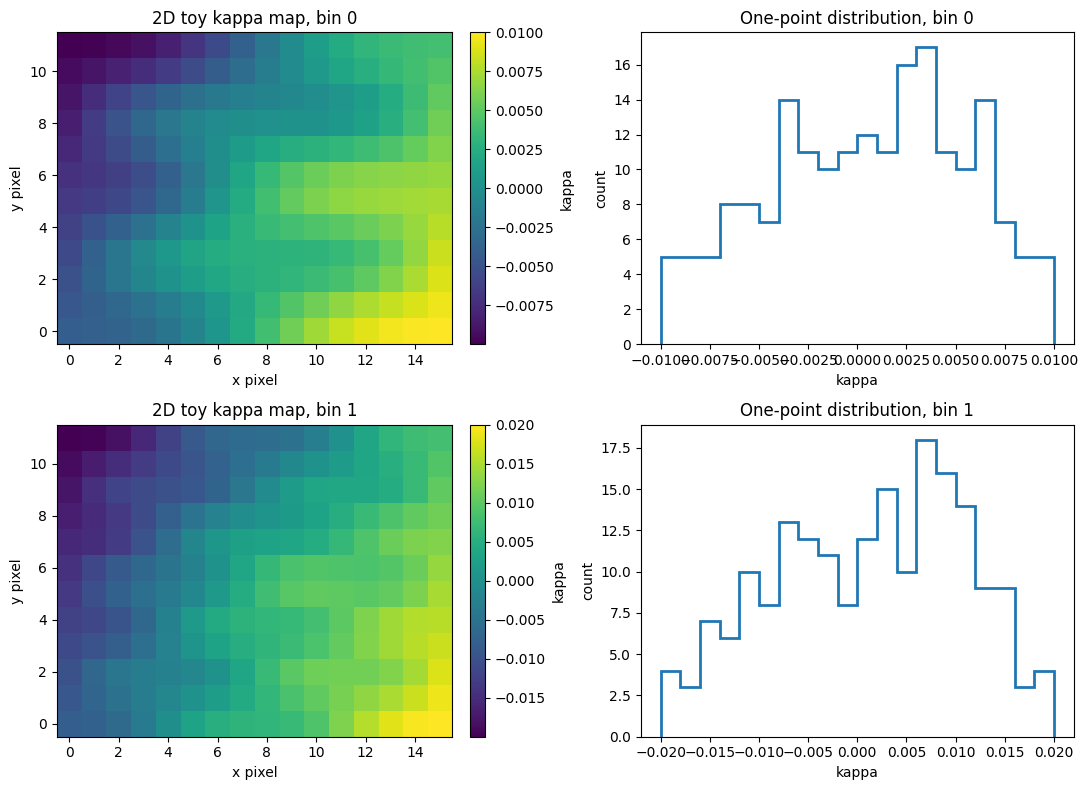

In [3]:
if plt is None:
    print("Install cosmock[plot] or matplotlib to render tutorial plots.")
else:
    fig, axes = plt.subplots(kappa_images.shape[0], 2, figsize=(11, 4 * kappa_images.shape[0]), squeeze=False)

    for bin_index, image in enumerate(kappa_images):
        image_ax = axes[bin_index, 0]
        hist_ax = axes[bin_index, 1]

        im = image_ax.imshow(image, origin="lower", cmap="viridis", aspect="auto")
        image_ax.set_title(f"2D toy kappa map, bin {bin_index}")
        image_ax.set_xlabel("x pixel")
        image_ax.set_ylabel("y pixel")
        fig.colorbar(im, ax=image_ax, fraction=0.046, pad=0.04, label="kappa")

        hist_ax.hist(image.ravel(), bins=20, histtype="step", linewidth=2)
        hist_ax.set_title(f"One-point distribution, bin {bin_index}")
        hist_ax.set_xlabel("kappa")
        hist_ax.set_ylabel("count")

    fig.tight_layout()
    show_plot(fig)

## 3. Calibrate from kappa maps

`KappaCalibration.from_maps(...)` validates map and spectrum shapes, stores the target spectra, and computes Gaussianized calibration samples used by the transform fit.

In [4]:
cal = cm.KappaCalibration.from_maps(
    kappa_maps,
    nside=nside,
    cl_ng=cl_ng,
    n_fit_bins=12,
)

print("n_bins", cal.n_bins)
print("n_pix", cal.n_pix)
print("binned transform points", [len(x) for x in cal.binned_x])

n_bins 2
n_pix 192
binned transform points [12, 12]


## 4. Fit a point transform from the calibration object

The user-facing fit operation is a method on `KappaCalibration` because it uses calibration state. The returned transform set stores one fitted transform per tomographic bin and can evaluate the fitted mapping.

In [5]:
transform_set = cal.fit_transform(order=order, constrained=False)
x_eval = np.linspace(-2.0, 2.0, 5)

print("transform order", transform_set.order)
print("transform params")
print(transform_set.transform_params)
print("bin 0 transform at x_eval")
print(transform_set.evaluate(x_eval, bin_index=0))

transform order 2
transform params
[[0.0073 0.6273]
 [0.0143 0.6187]]
bin 0 transform at x_eval
[-0.0091 -0.0046 -0.      0.0046  0.0092]


## 5. Plot the fitted point transforms

The fitted transform maps latent standard-normal values into kappa-like values. The scatter points show the binned calibration data that the transform is fitting.

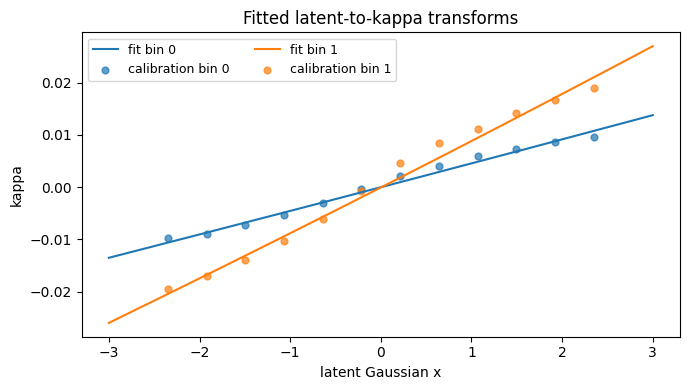

In [6]:
if plt is None:
    print("Install cosmock[plot] or matplotlib to render tutorial plots.")
else:
    x_grid = np.linspace(-3.0, 3.0, 200)
    fig, ax = plt.subplots(figsize=(7, 4))

    for bin_index in range(cal.n_bins):
        ax.plot(
            x_grid,
            transform_set.evaluate(x_grid, bin_index=bin_index),
            label=f"fit bin {bin_index}",
        )
        ax.scatter(
            cal.binned_x[bin_index],
            cal.binned_y[bin_index],
            s=24,
            alpha=0.7,
            label=f"calibration bin {bin_index}",
        )

    ax.set_title("Fitted latent-to-kappa transforms")
    ax.set_xlabel("latent Gaussian x")
    ax.set_ylabel("kappa")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    show_plot(fig)


## 6. Convert target spectra to latent Gaussian spectra

The fitted transform set also carries the operation that depends on fitted transform state: converting target kappa spectra into latent Gaussian spectra.

In [7]:
cl_x = transform_set.to_latent_spectra(n_jobs=1, quad_order=12)

print("cl_x", cl_x.shape)
print("finite", np.all(np.isfinite(cl_x)))
print("ell=2 covariance")
print(cl_x[:, :, 2])

cl_x (2, 2, 7)
finite True
ell=2 covariance
[[0.0536 0.0098]
 [0.0098 0.0285]]


## 7. Compare target and latent spectra

The target spectra describe the kappa field. The latent spectra describe the Gaussian field that will be sampled before applying the fitted point transform.

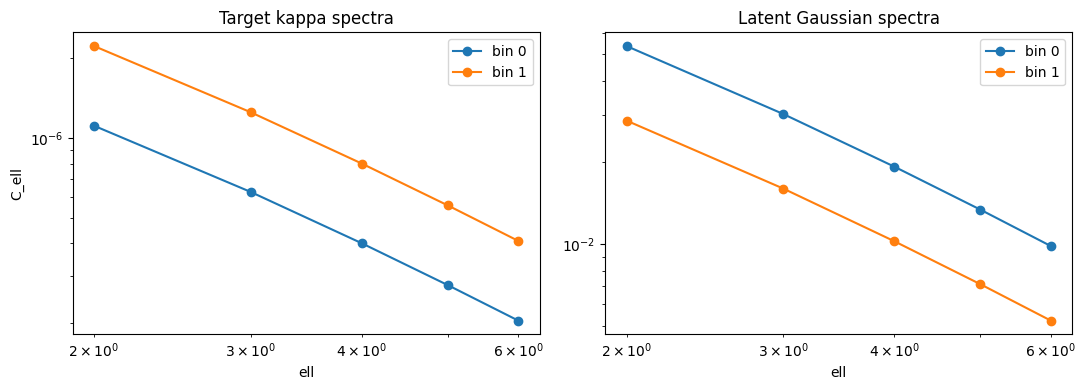

In [8]:
if plt is None:
    print("Install cosmock[plot] or matplotlib to render tutorial plots.")
else:
    ell = np.arange(cl_ng.shape[-1])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

    for bin_index in range(cal.n_bins):
        axes[0].loglog(ell[2:], cl_ng[bin_index, bin_index, 2:], marker="o", label=f"bin {bin_index}")
        axes[1].loglog(ell[2:], cl_x[bin_index, bin_index, 2:], marker="o", label=f"bin {bin_index}")

    axes[0].set_title("Target kappa spectra")
    axes[0].set_xlabel("ell")
    axes[0].set_ylabel("C_ell")
    axes[0].legend()

    axes[1].set_title("Latent Gaussian spectra")
    axes[1].set_xlabel("ell")
    axes[1].legend()

    fig.tight_layout()
    show_plot(fig)


## 8. Fit the full mock model

`MockModel.fit(...)` is the high-level model-building entry point. It fits the transform set, converts spectra, stores diagnostics, and keeps enough state for sampling and validation.

In [9]:
model = cm.MockModel.fit(
    cal,
    order=order,
    constrained=False,
    n_jobs=1,
    quad_order=12,
)

print("model order", model.order)
print("model lmax", model.lmax)
print("latent spectra ok", model.diagnostics()["cl_x"]["ok"])
print("model and transform_set agree", np.allclose(model.cl_x, cl_x))

model order 2
model lmax 6
latent spectra ok True
model and transform_set agree True


## 9. Validate mock-shaped arrays

`model.validate(...)` checks arrays with shape `(n_mocks, n_bins, n_pix)`. Without `healpy`, validation still reports finite values, mean and standard deviation comparisons, and histogram distances. Spectral validation is added automatically when `healpy` is available, or can be requested with `include_spectra=True`.

In [10]:
mock_like_maps = np.stack([
    cal.maps,
    cal.maps + 1e-4,
])
mock_like_images = mock_like_maps.reshape(mock_like_maps.shape[0], cal.n_bins, *map_shape)

report = model.validate(mock_like_maps, include_spectra=False)

print("report ok", report.ok)
print("histogram L1 by bin", report.histogram_l1_by_bin)
print("mean by bin", report.mean_by_bin)
print("target mean by bin", report.target_mean_by_bin)

report ok True
histogram L1 by bin [0.1042 0.1198]
mean by bin [0.0006 0.0012]
target mean by bin [0.0006 0.0011]


## 10. Plot validation maps and histograms

The validation report gives summary metrics. These plots show the original 2D calibration image, the mock-shaped mean image, and the one-point distribution comparison for each bin.

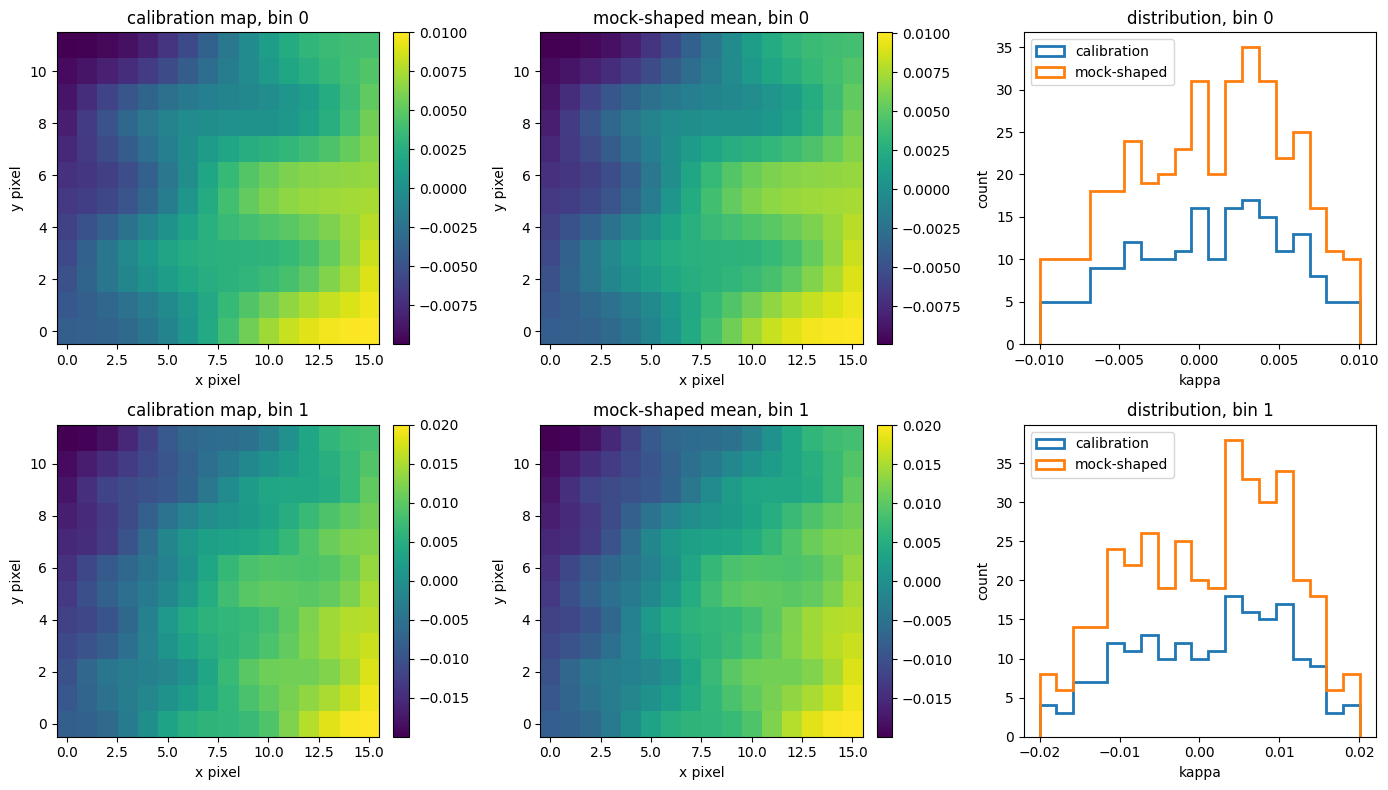

In [11]:
if plt is None:
    print("Install cosmock[plot] or matplotlib to render tutorial plots.")
else:
    fig, axes = plt.subplots(cal.n_bins, 3, figsize=(14, 4 * cal.n_bins), squeeze=False)

    for bin_index in range(cal.n_bins):
        target_image = cal.maps[bin_index].reshape(map_shape)
        mock_mean_image = mock_like_images[:, bin_index].mean(axis=0)
        mock_values = mock_like_images[:, bin_index].reshape(-1)

        target_ax, mock_ax, hist_ax = axes[bin_index]

        target_im = target_ax.imshow(target_image, origin="lower", cmap="viridis", aspect="auto")
        target_ax.set_title(f"calibration map, bin {bin_index}")
        target_ax.set_xlabel("x pixel")
        target_ax.set_ylabel("y pixel")
        fig.colorbar(target_im, ax=target_ax, fraction=0.046, pad=0.04)

        mock_im = mock_ax.imshow(mock_mean_image, origin="lower", cmap="viridis", aspect="auto")
        mock_ax.set_title(f"mock-shaped mean, bin {bin_index}")
        mock_ax.set_xlabel("x pixel")
        mock_ax.set_ylabel("y pixel")
        fig.colorbar(mock_im, ax=mock_ax, fraction=0.046, pad=0.04)

        lo = min(target_image.min(), mock_values.min())
        hi = max(target_image.max(), mock_values.max())
        bins = np.linspace(lo, hi, 20)
        hist_ax.hist(target_image.ravel(), bins=bins, histtype="step", linewidth=2, label="calibration")
        hist_ax.hist(mock_values, bins=bins, histtype="step", linewidth=2, label="mock-shaped")
        hist_ax.set_title(f"distribution, bin {bin_index}")
        hist_ax.set_xlabel("kappa")
        hist_ax.set_ylabel("count")
        hist_ax.legend()

    fig.tight_layout()
    show_plot(fig)

## 11. Optional: sample actual HEALPix mock maps

Sampling uses HEALPix harmonic transforms, so this section requires `healpy` via `pip install -e ".[healpix]"` or `pip install cosmock[healpix]` after packaging.

In [ ]:
try:
    import healpy  # noqa: F401
except ImportError:
    print("Skipping sampling because healpy is not installed. Install cosmock[healpix] to run this cell.")
else:
    mocks = model.sample(n_mocks=3, seed=1234, apply_pixwin=False)
    sample_report = model.validate(mocks, include_spectra=True)

    print("mocks", mocks.shape)
    print("finite", sample_report.finite)
    print("spectra available", sample_report.spectra_available)

OptionalDependencyError: Generating latent HEALPix maps requires the optional dependency 'healpy'. Install it with `pip install cosmock[healpix]`.

## 12. Replace the toy arrays with real inputs

For a real run, replace the synthetic data section with arrays loaded from your workflow. `cosmock` expects map arrays as `(n_bins, n_pix)`, so 2D image-like inputs should be flattened before calibration:

```python
kappa_images = np.load("path/to/kappa_images.npy")  # optional image form, (n_bins, ny, nx)
kappa_maps = kappa_images.reshape(kappa_images.shape[0], -1)

# Or load already-flat HEALPix-style maps directly:
kappa_maps = np.load("path/to/kappa_maps.npy")      # (n_bins, n_pix)

cl_ng = np.load("path/to/target_cls.npy")           # (n_bins, n_bins, lmax + 1)
pixwin = np.load("path/to/pixwin.npy")              # optional, (lmax + 1,)

cal = cm.KappaCalibration.from_maps(kappa_maps, nside=512, cl_ng=cl_ng, pixwin=pixwin)
model = cm.MockModel.fit(cal, order=3)
mocks = model.sample(n_mocks=100, seed=1234, apply_pixwin=True)
report = model.validate(mocks)
```
